# S7A — Bearing Measurement Uncertainty and Calibration

Independent continuous sequences define the statistical split. Overlapping frames are dependent residual samples, not independent trials. The result is a **calibrated bearing measurement benchmark, not tracking and not a signal-level CRLB**.

In [1]:
from pathlib import Path
import csv, json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'validation').exists():
    ROOT = ROOT.parent
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from validation.bearing_uncertainty_study import run_bearing_uncertainty_study
from model.bearing_statistics import tangent_residual
print('project root:', ROOT)

project root: c:\Users\leo\Documents\Stu\APM\7sem\diploma\uav_acoustic_model


In [2]:
covariance_records, quality_records = run_bearing_uncertainty_study(
    covariance_output_csv=ROOT / 'results' / 'bearing_covariance_summary.csv',
    quality_output_csv=ROOT / 'results' / 'bearing_quality_summary.csv',
)
print({'covariance_rows': len(covariance_records), 'quality_rows': len(quality_records)})

{'covariance_rows': 216, 'quality_rows': 1368}


In [3]:
evaluation = [r for r in covariance_records if r['split'] == 'evaluation']
calibration = [r for r in covariance_records if r['split'] == 'calibration']
assert len(calibration) == len(evaluation) == 108
assert all(r['covariance_symmetric'] and r['covariance_positive_semidefinite'] for r in covariance_records)
assert all(not r['evaluation_residual_used_to_fit_covariance'] for r in covariance_records)
assert all(not r['dependent_frames_are_independent_trials'] for r in covariance_records)
assert all(not r['truth_used_by_online_estimator'] for r in covariance_records)
cal_seeds = set(sum((json.loads(r['sequence_seeds_json']) for r in calibration[::3]), []))
eval_seeds = set(sum((json.loads(r['sequence_seeds_json']) for r in evaluation[::3]), []))
assert len(cal_seeds) == len(eval_seeds) == 108 and not cal_seeds.intersection(eval_seeds)
print({'calibration_sequences': len(cal_seeds), 'evaluation_sequences': len(eval_seeds),
       'dependent_frames_per_group_method': sorted({r['dependent_frame_count'] for r in covariance_records}),
       'coverage_range': (min(r['coverage'] for r in covariance_records), max(r['coverage'] for r in covariance_records))})

{'calibration_sequences': 108, 'evaluation_sequences': 108, 'dependent_frames_per_group_method': [60], 'coverage_range': (1.0, 1.0)}


## Evaluation NIS versus χ²(2)

The chi-square curve is only a diagnostic Gaussian benchmark. Calibration uses no evaluation residual.

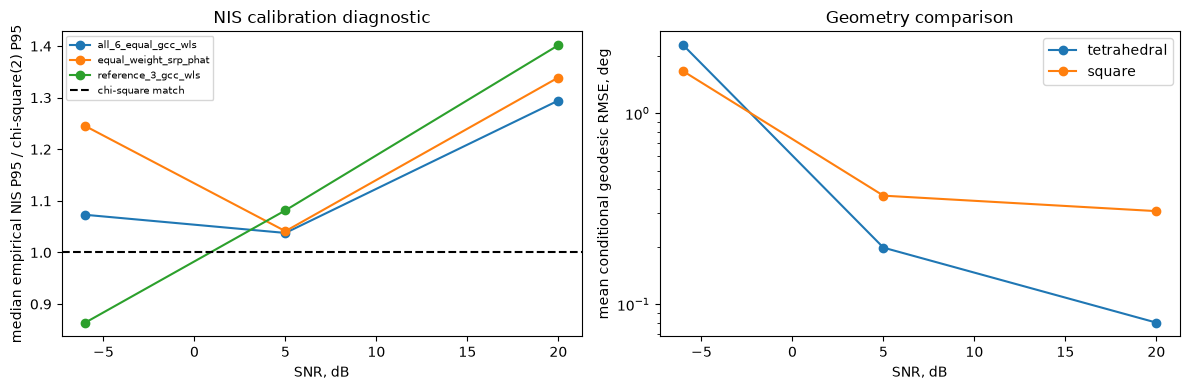

In [4]:
snrs = [-6.0, 5.0, 20.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method in sorted({r['estimator_variant'] for r in evaluation}):
    medians = []
    for snr in snrs:
        values = [r['nis_p95'] / r['chi_square_2_p95'] for r in evaluation if r['estimator_variant'] == method and r['snr_db'] == snr]
        medians.append(float(np.median(values)))
    axes[0].plot(snrs, medians, marker='o', label=method)
axes[0].axhline(1.0, color='black', linestyle='--', label='chi-square match')
axes[0].set(xlabel='SNR, dB', ylabel='median empirical NIS P95 / chi-square(2) P95', title='NIS calibration diagnostic')
axes[0].legend(fontsize=7)
for geometry in ('tetrahedral', 'square'):
    means = []
    for snr in snrs:
        values = [r['geodesic_rmse_deg'] for r in evaluation if r['geometry'] == geometry and r['snr_db'] == snr]
        means.append(float(np.mean(values)))
    axes[1].semilogy(snrs, means, marker='o', label=geometry)
axes[1].set(xlabel='SNR, dB', ylabel='mean conditional geodesic RMSE, deg', title='Geometry comparison')
axes[1].legend()
plt.tight_layout(); plt.show()

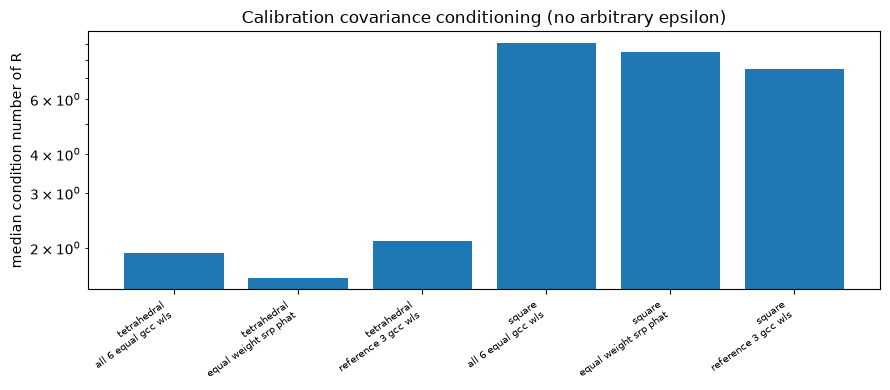

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
labels, conditions = [], []
for geometry in ('tetrahedral', 'square'):
    for method in sorted({r['estimator_variant'] for r in calibration}):
        selected = [r['covariance_condition_number'] for r in calibration if r['geometry'] == geometry and r['estimator_variant'] == method]
        labels.append(geometry + '\n' + method.replace('_', ' '))
        conditions.append(float(np.median(selected)))
ax.bar(np.arange(len(labels)), conditions)
ax.set_yscale('log'); ax.set_ylabel('median condition number of R'); ax.set_xticks(np.arange(len(labels)), labels, rotation=35, ha='right', fontsize=7)
ax.set_title('Calibration covariance conditioning (no arbitrary epsilon)')
plt.tight_layout(); plt.show()

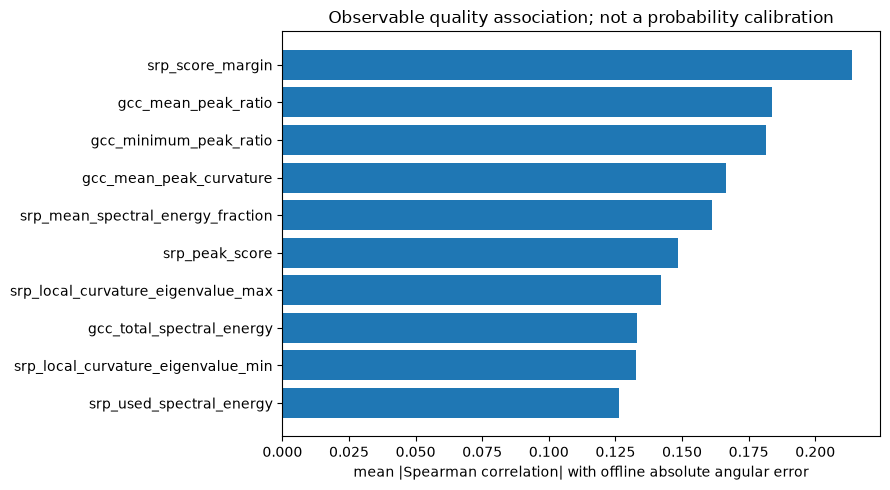

{'nis_p95_ratio_min': np.float64(0.09668642514099193), 'median': np.float64(1.153472129998407), 'max': np.float64(2.7850823115509824), 'groups_with_ratio_0.5_to_1.5': 77, 'evaluation_groups': 108}


In [6]:
finite_quality = [r for r in quality_records if r['spearman_correlation_with_absolute_angular_error'] is not None]
metric_names = sorted({r['quality_metric'] for r in finite_quality})
mean_abs = [np.mean([abs(r['spearman_correlation_with_absolute_angular_error']) for r in finite_quality if r['quality_metric'] == name]) for name in metric_names]
order = np.argsort(mean_abs)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(np.asarray(metric_names)[order], np.asarray(mean_abs)[order])
ax.set_xlabel('mean |Spearman correlation| with offline absolute angular error')
ax.set_title('Observable quality association; not a probability calibration')
plt.tight_layout(); plt.show()
ratios = np.asarray([r['nis_p95'] / r['chi_square_2_p95'] for r in evaluation])
print({'nis_p95_ratio_min': ratios.min(), 'median': np.median(ratios), 'max': ratios.max(),
       'groups_with_ratio_0.5_to_1.5': int(np.sum((ratios >= .5) & (ratios <= 1.5))),
       'evaluation_groups': len(ratios)})